# BiLSTM-CRF

In [1]:
import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import pandas as pd
import tensorflow_addons as tfa

In [3]:
batch_size = 32

## Import dan load data

In [ ]:
dataset =  load_dataset('ncbi_disease')
train =  dataset['train'].to_pandas()
validation =  dataset['validation'].to_pandas()
test = dataset['test'].to_pandas()
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 18546
    })
    validation: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 3856
    })
})


In [5]:
train.head()

,id,tokens,ner_tags
0,1,"[IL-2, gene, expression, and, NF-kappa, B, act...","[1, 2, 0, 0, 9, 10, 0, 0, 9, 0, 0, 0, 0, 0, 9, 0]"
1,2,"[Activation, of, the, CD28, surface, receptor,...","[0, 0, 0, 9, 10, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0..."
2,3,"[In, primary, T, lymphocytes, we, show, that, ...","[0, 7, 8, 8, 0, 0, 0, 9, 0, 0, 0, 0, 0, 0, 0, ..."
3,4,"[Delineation, of, the, CD28, signaling, cascad...","[0, 0, 0, 9, 0, 0, 0, 0, 0, 0, 9, 10, 10, 0, 0..."
4,5,"[Our, data, suggest, that, lipoxygenase, metab...","[0, 0, 0, 0, 9, 10, 0, 0, 0, 0, 0, 0, 9, 0, 0,..."


## Word indexing

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

def tokenize_texts(train_df, validation_df, test_df=None, column='tokens', filters=''):
    # Join tokens into strings
    train_tokens = [' '.join(tokens) for tokens in train_df[column].tolist()]
    validation_tokens = [' '.join(tokens) for tokens in validation_df[column].tolist()]

    # If test_df is provided, join its tokens as well
    test_tokens = []
    if test_df is not None:
        test_tokens = [' '.join(tokens) for tokens in test_df[column].tolist()]

    # Initialize the tokenizer
    tokenizer = Tokenizer(filters=filters)

    # Fit the tokenizer on the combined tokens (train + validation + test if provided)
    tokenizer.fit_on_texts(train_tokens + validation_tokens + test_tokens)

    # Convert the tokens to sequences
    train_inputs = tokenizer.texts_to_sequences(train_tokens)
    validation_inputs = tokenizer.texts_to_sequences(validation_tokens)

    if test_df is not None:
        test_inputs = tokenizer.texts_to_sequences(test_tokens)
        return train_inputs, validation_inputs, test_inputs, tokenizer

    return train_inputs, validation_inputs, test_inputs, tokenizer


In [ ]:
train_inputs, validation_inputs, test_inputs, tokenizer = tokenize_texts(train, validation, test, column='tokens')

In [ ]:
print(len(train_inputs))
print(len(validation_inputs))
print(len(test_inputs))

18546
3856


In [9]:
# Index dari hasil tokenizer
print("Word Index:", tokenizer.word_index)

Word Index: {'the': 1, 'of': 2, '.': 3, ',': 4, 'in': 5, 'and': 6, 'to': 7, ')': 8, '(': 9, 'a': 10, 'cells': 11, 'that': 12, 'by': 13, 'with': 14, 'is': 15, 'expression': 16, 'was': 17, 'cell': 18, 'for': 19, 'b': 20, 't': 21, 'we': 22, 'human': 23, 'activation': 24, 'gene': 25, 'transcription': 26, 'as': 27, 'this': 28, 'protein': 29, 'these': 30, 'binding': 31, 'from': 32, 'not': 33, 'were': 34, 'an': 35, 'or': 36, 'factor': 37, 'on': 38, 'activity': 39, 'are': 40, 'receptor': 41, 'which': 42, 'promoter': 43, 'be': 44, 'nuclear': 45, 'nf-kappa': 46, 'have': 47, 'but': 48, 'at': 49, 'both': 50, 'proteins': 51, 'also': 52, 'lymphocytes': 53, 'patients': 54, '1': 55, 'alpha': 56, 'genes': 57, 'results': 58, 'factors': 59, 'may': 60, ':': 61, 'il-2': 62, 'differentiation': 63, 'induction': 64, 'mrna': 65, 'response': 66, 'levels': 67, 'induced': 68, 'role': 69, 'site': 70, 'dna': 71, 'activated': 72, 'transcriptional': 73, 'two': 74, 'nf-kappab': 75, 'kappa': 76, 'kinase': 77, 'been': 7

In [10]:
print(len(train_inputs[2764]))
print(len(train['tokens'].iloc[2764]))

41
41


In [11]:
tokens = train_inputs[2764]

# Print tokens and their corresponding indices
print("Token Index\tToken")
for token in tokens:
    print(f"{token}\t\t{tokenizer.index_word[token]}")

Token Index	Token
94		increased
145		proliferation
4		,
1158		cytotoxicity
4		,
6		and
25		gene
16		expression
98		after
88		stimulation
2		of
23		human
127		peripheral
106		blood
21		t
53		lymphocytes
107		through
10		a
266		surface
8158		ganglioside
9		(
8159		gd3
8		)
200		[
1801		published
2462		erratum
468		appears
5		in
1538		j
8149		immunol
6779		1994
6938		jul
792		15
85		;
9958		153
9		(
124		2
8		)
61		:
13782		910
197		]


## Padding

In [ ]:
train_labels = train['ner_tags'].to_list()
validation_labels = validation['ner_tags'].to_list()
test_labels = test['ner_tags'].to_list()

In [13]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [14]:
def pad_sequences_to_max_length(train_inputs, validation_inputs, test_inputs=None, train_targets=None, validation_targets=None, test_targets=None, padding='post'):
    # Hitung max_length dari training, validation, dan test inputs (jika ada)
    max_length_train = max(len(sent) for sent in train_inputs)
    max_length_validation = max(len(sent) for sent in validation_inputs)

    if test_inputs is not None:
        max_length_test = max(len(sent) for sent in test_inputs)
    else:
        max_length_test = 0  # Jika tidak ada test set, anggap 0

    # Tentukan max_length global
    max_length = max(max_length_train, max_length_validation, max_length_test)
    print("Max sequence length:", max_length)

    # Lakukan padding pada train, validation, dan test inputs (jika ada)
    train_inputs_final = pad_sequences(train_inputs, maxlen=max_length, padding=padding)
    print("Shape of train inputs:", train_inputs_final.shape)

    validation_inputs_final = pad_sequences(validation_inputs, maxlen=max_length, padding=padding)
    print("Shape of validation inputs:", validation_inputs_final.shape)

    if test_inputs is not None:
        test_inputs_final = pad_sequences(test_inputs, maxlen=max_length, padding=padding)
        print("Shape of test inputs:", test_inputs_final.shape)
    else:
        test_inputs_final = None

    # Lakukan padding pada train, validation, dan test targets
    train_targets_final = pad_sequences(train_targets, maxlen=max_length, padding=padding)
    print("Shape of train targets:", train_targets_final.shape)

    validation_targets_final = pad_sequences(validation_targets, maxlen=max_length, padding=padding)
    print("Shape of validation targets:", validation_targets_final.shape)

    if test_targets is not None:
        test_targets_final = pad_sequences(test_targets, maxlen=max_length, padding=padding)
        print("Shape of test targets:", test_targets_final.shape)
    else:
        test_targets_final = None

    return train_inputs_final, validation_inputs_final, test_inputs_final, train_targets_final, validation_targets_final, test_targets_final


In [ ]:

train_final, validation_final, test_final, train_labels_final, validation_labels_final, test_labels_final = pad_sequences_to_max_length(train_inputs,
                                                                                                                                        validation_inputs,
                                                                                                                                        test_inputs,
                                                                                                                                        train_labels,
                                                                                                                                        validation_labels,
                                                                                                                                        test_labels)

Max sequence length: 208
Shape of train inputs: (18546, 208)
Shape of validation inputs: (3856, 208)
Shape of train targets: (18546, 208)
Shape of validation targets: (3856, 208)


In [16]:
train_final[0]

array([  62,   25,   16,    6,   46,   20,   24,  107,  420,  535,  822,
        925,  114,   13, 2513,    3,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

In [17]:
train_labels_final[0]

array([ 1,  2,  0,  0,  9, 10,  0,  0,  9,  0,  0,  0,  0,  0,  9,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0])

## Modelling

In [18]:
max_length = 208
unique_tags = set(tag for tags in train_labels_final for tag in tags)
num_unique_tags = len(unique_tags)
print(num_unique_tags)

11


In [19]:
from tensorflow.keras.utils import to_categorical

In [ ]:
train_labels_final_encoded = to_categorical(train_labels_final, num_classes=num_unique_tags)
validation_labels_final_encoded = to_categorical(validation_labels_final, num_classes=num_unique_tags)
test_labels_final_encoded = to_categorical(test_labels_final, num_classes=num_unique_tags)

In [21]:
from tensorflow.keras.layers import LSTM, Embedding, Dense, Dropout, Input, TimeDistributed, Bidirectional
from tensorflow.keras.models import Model
from tensorflow_addons.layers import CRF
import tensorflow_addons as tfa
from tensorflow_addons.losses import SigmoidFocalCrossEntropy
from tensorflow_addons.optimizers import AdamW

# Define input layer
inputs = Input(shape=(max_length,))  # max_length should be defined

# Add Embedding layer
embeddings = Embedding(input_dim=len(tokenizer.word_index)+1,
                       input_length=max_length,
                       mask_zero=True,
                       output_dim=300)(inputs)

# Add LSTM layer
lstm_output = Bidirectional(LSTM(units=128, return_sequences=True))(embeddings)
dense_output = TimeDistributed(Dense(32, activation='relu'))(lstm_output)

# Add the CRF layer
crf = CRF(num_unique_tags)  # num_classes should be the number of unique NER tags (including '0')
predicted_sequence, potentials, sequence_length, crf_kernel= crf(dense_output)

# Create the model
model = Model(inputs, potentials)
# Compile the model
model.compile(optimizer='adam', loss=SigmoidFocalCrossEntropy(), metrics=['accuracy'])
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 208)]             0         
                                                                 
 embedding (Embedding)       (None, 208, 300)          6803700   
                                                                 
 bidirectional (Bidirectiona  (None, 208, 256)         439296    
 l)                                                              
                                                                 
 time_distributed (TimeDistr  (None, 208, 32)          8224      
 ibuted)                                                         
                                                                 
 crf (CRF)                   [(None, 208),             506       
                              (None, 208, 11),                   
                              (None,),                       

### Callback

In [22]:
from tensorflow.keras.callbacks import Callback
import os
import pandas as pd

class HistoryCSVAppendCallback(Callback):
    def __init__(self, filepath):
        super(HistoryCSVAppendCallback, self).__init__()
        self.filepath = filepath
        self.first_epoch = not os.path.exists(filepath)  # Check if file exists
    
    def on_epoch_end(self, epoch, logs=None):
        # Convert logs to a pandas DataFrame
        epoch_history = pd.DataFrame(logs, index=[epoch])
        
        # If file doesn't exist, create it with the header, otherwise append
        if self.first_epoch:
            epoch_history.to_csv(self.filepath, mode='w', header=True)
            self.first_epoch = False
        else:
            epoch_history.to_csv(self.filepath, mode='a', header=False)

# Define file paths for saving model and history
history_filepath = f'./history/BILSTM_CRF_{batch_size}.csv'

history_callback = HistoryCSVAppendCallback(filepath=history_filepath)


In [23]:
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint_callback = ModelCheckpoint(
    filepath=f"./Model/BILSTM_CRF_{batch_size}.h5",  
    monitor="val_loss",              
    save_best_only=True,            
    save_weights_only=False,         
    verbose=1
)

In [24]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    mode="min",
    verbose=1
)

In [25]:
callbacks = [history_callback, early_stopping, checkpoint_callback]

In [26]:
history = model.fit(train_final, train_labels_final_encoded, epochs=100, validation_data=(validation_final, validation_labels_final_encoded), batch_size=batch_size, callbacks=callbacks)

Epoch 1/100
578/580 [============================>.] - ETA: 0s - loss: 0.1082 - accuracy: 0.9784
Epoch 1: val_loss improved from inf to 0.00898, saving model to ./Model\BILSTM_CRF_32.h5
580/580 [==============================] - 23s 28ms/step - loss: 0.1080 - accuracy: 0.9784 - val_loss: 0.0090 - val_accuracy: 0.9860
Epoch 2/100
578/580 [============================>.] - ETA: 0s - loss: 0.0060 - accuracy: 0.9901
Epoch 2: val_loss improved from 0.00898 to 0.00826, saving model to ./Model\BILSTM_CRF_32.h5
580/580 [==============================] - 13s 23ms/step - loss: 0.0060 - accuracy: 0.9901 - val_loss: 0.0083 - val_accuracy: 0.9885
Epoch 3/100
578/580 [============================>.] - ETA: 0s - loss: 0.0043 - accuracy: 0.9933
Epoch 3: val_loss did not improve from 0.00826
580/580 [==============================] - 13s 23ms/step - loss: 0.0043 - accuracy: 0.9933 - val_loss: 0.0102 - val_accuracy: 0.9890
Epoch 4/100
579/580 [============================>.] - ETA: 0s - loss: 0.0032 - a

In [27]:
# history_df= pd.DataFrame(history.history)
# history_df.to_csv('bilstm_crf_ncbi_history', index=True)

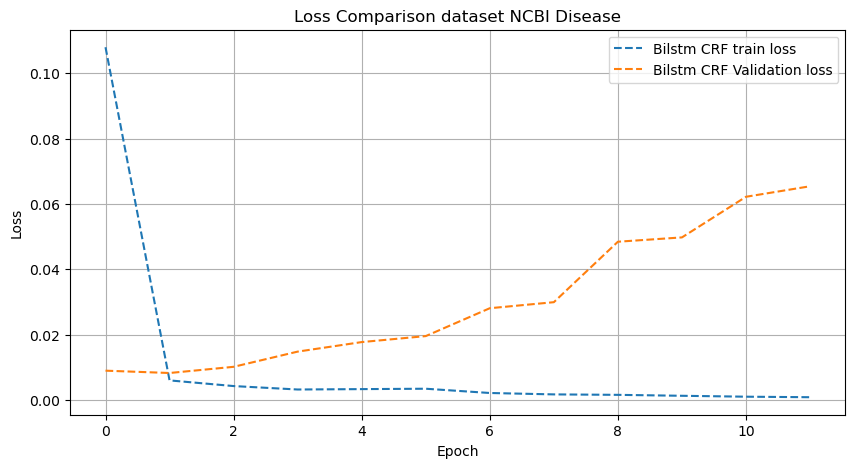

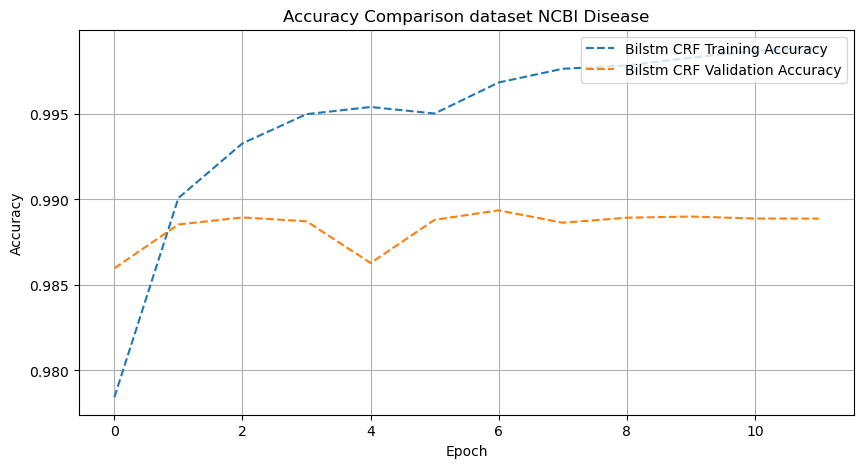

In [28]:
history = history.history

plt.figure(figsize=(10, 5))
plt.plot(history['loss'], label='Bilstm CRF train loss', linestyle='--')
plt.plot(history['val_loss'], label='Bilstm CRF Validation loss', linestyle='--')
plt.title('Loss Comparison dataset NCBI Disease')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history['accuracy'], label='Bilstm CRF Training Accuracy', linestyle='--')
plt.plot(history['val_accuracy'], label='Bilstm CRF Validation Accuracy', linestyle='--')
plt.title('Accuracy Comparison dataset NCBI Disease')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid()
plt.show()

In [29]:
# model.save('bilstm_crf_ncbi_32.h5')

In [30]:
# inference_model = Model(inputs, predicted_sequence)

In [31]:
from tensorflow.keras.models import load_model
model =  load_model(f"./Model/BILSTM_CRF_{batch_size}.h5")

In [ ]:
from sklearn.metrics import classification_report
import numpy as np
import tensorflow as tf
import seaborn as sns

# Assuming you have already trained your model
label_names = [
    'O',
    'B-DNA',
    'I-DNA',
    'B-RNA',
    'I-RNA',
    'B-cell_line',
    'I-cell_line',
    'B-cell_type',
    'I-cell_type',
    'B-protein',
    'I-protein',
]
# Get predictions from the model
y_pred = model.predict(test_final)  # X_test is your test data

# Convert predictions to integer labels
y_pred_labels = np.argmax(y_pred, axis=-1)

# Flatten true and predicted labels for classification report
y_true_labels = np.argmax(test_labels_final_encoded, axis=-1)  # y_test is your true labels

# Generate classification report (you can replace num_classes with the number of unique tags)
report = classification_report(y_true_labels.flatten(), y_pred_labels.flatten(), labels=range(num_unique_tags), target_names=label_names)

# Print the classification report
print(report)

121/121 [==============================] - 3s 10ms/step
              precision    recall  f1-score   support

           O       0.99      1.00      1.00    782656
       B-DNA       0.67      0.51      0.58      1056
       I-DNA       0.76      0.70      0.73      1789
       B-RNA       0.78      0.38      0.51       118
       I-RNA       0.62      0.63      0.63       187
 B-cell_line       0.65      0.47      0.54       500
 I-cell_line       0.65      0.62      0.63       989
 B-cell_type       0.75      0.57      0.65      1921
 I-cell_type       0.85      0.60      0.71      2991
   B-protein       0.69      0.73      0.71      5067
   I-protein       0.73      0.69      0.71      4774

    accuracy                           0.99    802048
   macro avg       0.74      0.63      0.67    802048
weighted avg       0.99      0.99      0.99    802048



In [33]:
with open(f"./cr/BiLSTM_CRF_{batch_size}.txt", "w") as file:
     file.write(report)

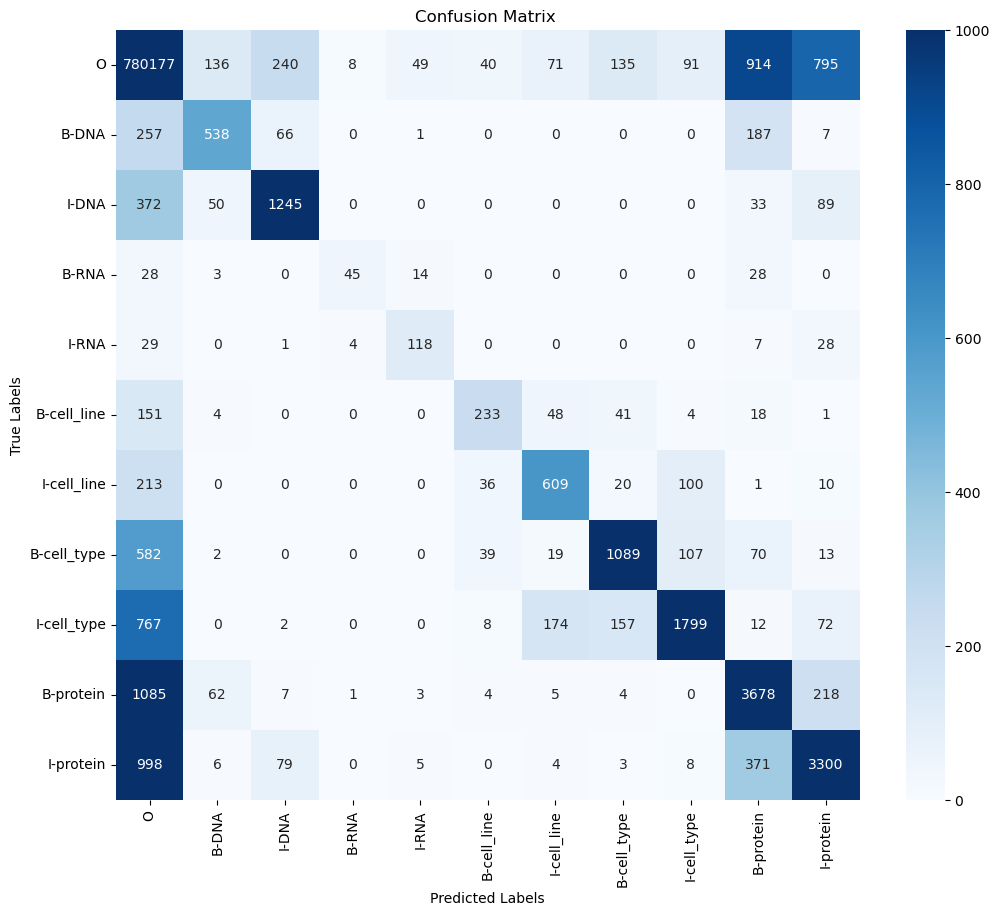

In [ ]:
from sklearn.metrics import confusion_matrix

y_true_flat = y_true_labels.flatten()
y_pred_flat = y_pred_labels.flatten()

cm = confusion_matrix(y_true_flat, y_pred_flat, labels=range(len(label_names)))

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_names,
    yticklabels=label_names,
    cmap='Blues',
    vmax=3000
)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix ')
plt.savefig(f"./cm/BiLSTM_CRF_{batch_size}.png", format='png')
plt.show()
